In [37]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc
import scipy
from itertools import combinations
import pycwt
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import mixture
import statistics

from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import mutual_info_score

from itertools import combinations
from sklearn.model_selection import PredefinedSplit

from scipy.stats import zscore

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from scipy.stats import ttest_1samp

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

datadir = "/jukebox/hasson/snastase/social-ctf/results"
lstmsNew = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

In [2]:
def mutual_info_binned(x, y, bins=None):
    if not bins:
        bins = int(np.floor(np.sqrt(4501 / 5)))
    c_xy = np.histogram2d(x, y, bins)[0]
    mi = mutual_info_score(None, None, contingency=c_xy)
    return mi

In [38]:
n_repeats = 32
n_maps = 32
n_samples = 4501
n_players = 4
n_pairs = n_players * (n_players - 1) / 2
pairs = combinations(np.arange(n_players), 2)
n_pcs = 142

In [39]:
# data shape = (2 repeats, 4 players, 4501 samples, 142 PCs)
lstms = np.full((n_maps, n_repeats, n_samples, n_players, n_pcs), np.nan)
map_ids = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map_id}_repeat-{repeat_id}.npy')
        lstms[map_id, repeat_id] = zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
        map_ids.extend([map_id]*n_samples)
    print(f'Finished loading {map_id}')
print(f"LSTMs shape: {lstms.shape}")
    
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
print(f"LSTMs stack shape: {lstms_stack.shape}")

MemoryError: Unable to allocate 19.5 GiB for an array with shape (32, 32, 4501, 4, 142) and data type float64

In [39]:
lstms_stack = np.dstack(np.split(lstms, n_repeats, axis=1)).squeeze() #32 x 144032 x 2
lstms_stack = np.hstack(np.split(lstms_stack, n_maps, axis=0)).squeeze()
lstms_stack.shape

(4609024, 4, 142)

In [95]:
lstms_stack.shape

(4609024, 4, 142)

In [96]:
np.save('lstms_stack.npy', lstms_stack)

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import PredefinedSplit
cv = PredefinedSplit(map_ids)

results = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(50): #n_pcs
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 0
Finished ISC regression for PC 2, pair 1
Finished ISC regression for PC 2, pair 2
Finished ISC regression for PC 2, pair 3
Finished ISC regression for PC 2, pair 4
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 0
Finished ISC regression for PC 3, pair 1
Finished ISC regression for PC 3, pair 2
Finished ISC regression for PC 3, pair 3
Finished ISC regression for PC 3, pair 4
Finished ISC regression for PC 3, pair 5
Finished ISC reg

In [12]:
for pc_id in np.arange(100,n_pcs): #n_pcs
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0], pc_id][:, np.newaxis], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0], pc_id][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 100, pair 0
Finished ISC regression for PC 100, pair 1
Finished ISC regression for PC 100, pair 2
Finished ISC regression for PC 100, pair 3
Finished ISC regression for PC 100, pair 4
Finished ISC regression for PC 100, pair 5
Finished ISC regression for PC 101, pair 0
Finished ISC regression for PC 101, pair 1
Finished ISC regression for PC 101, pair 2
Finished ISC regression for PC 101, pair 3
Finished ISC regression for PC 101, pair 4
Finished ISC regression for PC 101, pair 5
Finished ISC regression for PC 102, pair 0
Finished ISC regression for PC 102, pair 1
Finished ISC regression for PC 102, pair 2
Finished ISC regression for PC 102, pair 3
Finished ISC regression for PC 102, pair 4
Finished ISC regression for PC 102, pair 5
Finished ISC regression for PC 103, pair 0
Finished ISC regression for PC 103, pair 1
Finished ISC regression for PC 103, pair 2
Finished ISC regression for PC 103, pair 3
Finished ISC regression for PC 103, pair 4
Finished IS

In [13]:
results[141]

array([[ 0.05484523,  0.13323616,  0.06903976, ...,  0.03356966,
         0.08837673,  0.06913813],
       [-0.04155279, -0.04875029,  0.02500249, ..., -0.00250315,
         0.0011494 ,  0.03771705],
       [-0.01373049, -0.03090669, -0.00588556, ...,  0.02879681,
         0.02910099, -0.00147247],
       [-0.00607342, -0.0252036 ,  0.03664364, ..., -0.0043242 ,
         0.00531012,  0.06921938],
       [-0.06142289, -0.03985055, -0.00029069, ...,  0.00136726,
        -0.03633371,  0.06467134],
       [ 0.11045286,  0.08290671,  0.12158667, ...,  0.06162716,
         0.01700426,  0.03507014]])

In [18]:
np.save('regression_results.npy', results)

In [6]:
results = np.load('regression_results.npy')

In [26]:
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        print(f'PC {pc_id}, pair {pair_id}:',ttest_1samp(results[pc_id, pair_id], popmean=0))

PC 0, pair 0: Ttest_1sampResult(statistic=5.8859596712621896, pvalue=5.359789944398993e-09)
PC 0, pair 1: Ttest_1sampResult(statistic=31.076964722834923, pvalue=7.547845112830879e-150)
PC 0, pair 2: Ttest_1sampResult(statistic=31.643970460196865, pvalue=8.642087349469478e-154)
PC 0, pair 3: Ttest_1sampResult(statistic=29.004000809485994, pvalue=1.818967065213759e-135)
PC 0, pair 4: Ttest_1sampResult(statistic=31.564937758266943, pvalue=3.0622025276267557e-153)
PC 0, pair 5: Ttest_1sampResult(statistic=5.619803227668935, pvalue=2.4642224544281334e-08)
PC 1, pair 0: Ttest_1sampResult(statistic=58.04700445971611, pvalue=0.0)
PC 1, pair 1: Ttest_1sampResult(statistic=91.66984911339972, pvalue=0.0)
PC 1, pair 2: Ttest_1sampResult(statistic=92.47206170828842, pvalue=0.0)
PC 1, pair 3: Ttest_1sampResult(statistic=93.07434944121682, pvalue=0.0)
PC 1, pair 4: Ttest_1sampResult(statistic=91.53523565421271, pvalue=0.0)
PC 1, pair 5: Ttest_1sampResult(statistic=59.490285252453894, pvalue=0.0)
PC 2

In [60]:
results.shape

(142, 6, 1024)

In [28]:
for pc_id in np.arange(n_pcs):
    print(f'PC {pc_id}, cooperative pairs:',ttest_1samp(np.mean(results[pc_id, (0,5)], axis=0), popmean=0))
    print(f'PC {pc_id}, competitive pairs:',ttest_1samp(np.mean(results[pc_id, 1:4], axis=0), popmean=0))

PC 0, cooperative pairs: Ttest_1sampResult(statistic=7.8908639122784345, pvalue=7.682688662945102e-15)
PC 0, competitive pairs: Ttest_1sampResult(statistic=54.63380535713738, pvalue=1.32669722660908e-305)
PC 1, cooperative pairs: Ttest_1sampResult(statistic=77.38871712967482, pvalue=0.0)
PC 1, competitive pairs: Ttest_1sampResult(statistic=143.11373972307393, pvalue=0.0)
PC 2, cooperative pairs: Ttest_1sampResult(statistic=117.39570128408569, pvalue=0.0)
PC 2, competitive pairs: Ttest_1sampResult(statistic=225.2394439700194, pvalue=0.0)
PC 3, cooperative pairs: Ttest_1sampResult(statistic=33.8038774024213, pvalue=8.472083180294352e-169)
PC 3, competitive pairs: Ttest_1sampResult(statistic=44.46004658848693, pvalue=3.263181300739145e-241)
PC 4, cooperative pairs: Ttest_1sampResult(statistic=457.3831049857518, pvalue=0.0)
PC 4, competitive pairs: Ttest_1sampResult(statistic=9.738797090797519, pvalue=1.708027104540847e-21)
PC 5, cooperative pairs: Ttest_1sampResult(statistic=56.8981932963

In [14]:
np.mean(results[pc_id, (0,5)], axis=0).shape

(1024,)

In [29]:
for pc_id in np.arange(n_pcs):
    print(f'PC {pc_id}, difference:',ttest_1samp(np.mean(results[pc_id, (0,5)], axis=0) - 
                                                 np.mean(results[pc_id, 1:4], axis=0), popmean=0))

PC 0, difference: Ttest_1sampResult(statistic=-22.840364651736753, pvalue=1.235785120648863e-93)
PC 1, difference: Ttest_1sampResult(statistic=-43.55506542600773, pvalue=3.1264804869071562e-235)
PC 2, difference: Ttest_1sampResult(statistic=-133.69041078973248, pvalue=0.0)
PC 3, difference: Ttest_1sampResult(statistic=-0.5279792613340066, pvalue=0.5976282315969528)
PC 4, difference: Ttest_1sampResult(statistic=218.99422382700854, pvalue=0.0)
PC 5, difference: Ttest_1sampResult(statistic=19.492042802905086, pvalue=3.314021040981182e-72)
PC 6, difference: Ttest_1sampResult(statistic=37.12497530019157, pvalue=9.408664869678509e-192)
PC 7, difference: Ttest_1sampResult(statistic=-35.1366071288932, pvalue=4.902406640232748e-178)
PC 8, difference: Ttest_1sampResult(statistic=62.159013146092505, pvalue=0.0)
PC 9, difference: Ttest_1sampResult(statistic=90.61037296648597, pvalue=0.0)
PC 10, difference: Ttest_1sampResult(statistic=68.13503683296452, pvalue=0.0)
PC 11, difference: Ttest_1sampRes

In [16]:
np.mean(results[pc_id, (0,5)], axis=0) - np.mean(results[pc_id, 1:4], axis=0)

array([-0.04150639, -0.00397083, -0.05184933, ..., -0.06666458,
       -0.02947389,  0.00146351])

In [32]:
results_df_dict = {'PC': [], 'cooperative cvISC': []}

coop_ids = (0, 5)
for pc_id in np.arange(50):  #n_pcs
    for game_id in np.arange(n_maps * n_repeats):
        results_df_dict['cooperative cvISC'].append(
            np.mean(results[pc_id, coop_ids, game_id], axis=0))
        results_df_dict['PC'].append(pc_id + 1)

results_df = pd.DataFrame(results_df_dict)

In [32]:
results_df_dict_full = {'PC': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'cooperative-competitive cvISC difference': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps * n_repeats):
        coop = np.mean(results[pc_id, coop_ids, game_id], axis=0)
        comp = np.mean(results[pc_id, comp_ids, game_id], axis=0)
        results_df_dict_full['cooperative cvISC'].append(coop)
        results_df_dict_full['competitive cvISC'].append(comp)
        results_df_dict_full['cooperative-competitive cvISC difference'].append(coop-comp)
        results_df_dict_full['PC'].append(pc_id + 1)

results_df_full = pd.DataFrame(results_df_dict_full)

In [21]:
#append stuff
results_df_dict_full = {'PC': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'coop/comp difference cvISC': []}

coop_ids = (0, 5)
for pc_id in np.arange(20,24):  #n_pcs
    for game_id in np.arange(n_maps * n_repeats):
        coop = np.mean(results[pc_id, coop_ids, game_id], axis=0)
        comp = np.mean(results[pc_id, comp_ids, game_id], axis=0)
        results_df_dict_full['cooperative cvISC'].append(coop)
        results_df_dict_full['competitive cvISC'].append(comp)
        results_df_dict_full['coop/comp difference cvISC'].append(coop-comp)
        results_df_dict_full['PC'].append(pc_id + 1)

results_df_temp = pd.DataFrame(results_df_dict_full)
results_df_full_2 = pd.concat([results_df_full, results_df_temp])

(0.0, 0.6)

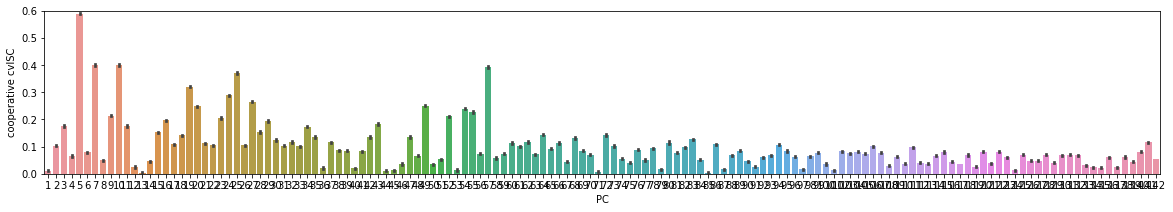

In [72]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_full)
ax.set_ylim(0, .6)

(0.0, 0.6)

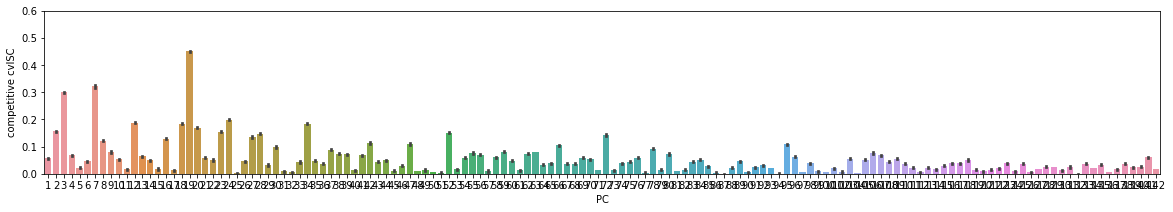

In [73]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='competitive cvISC', data=results_df_full, ax=ax)
ax.set_ylim(0, .6)

(-0.6, 0.6)

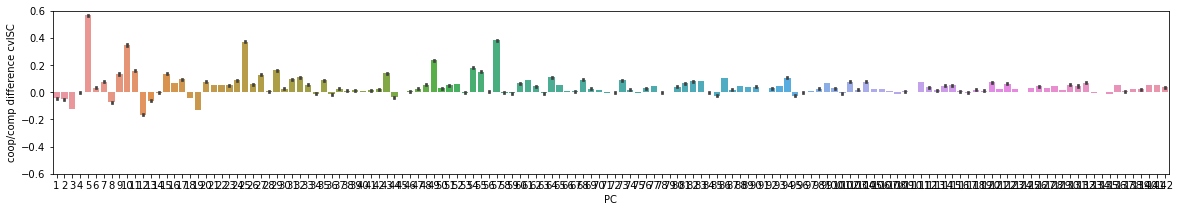

In [74]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='coop/comp difference cvISC', data=results_df_full, ax=ax)
ax.set_ylim(-0.6, .6)

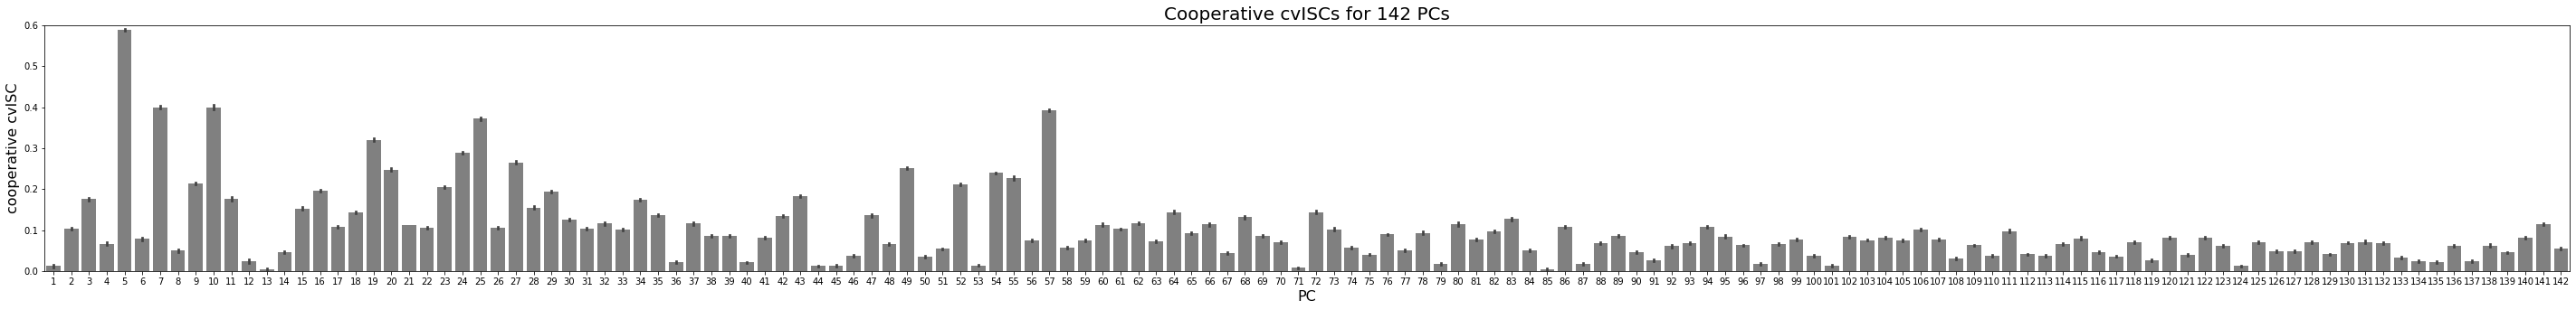

In [49]:
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_full, color='gray')
ax.set_ylim(0, .6)
ax.set_title('Cooperative cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('cooperative cvISC', fontsize=16);
fig.savefig("coop_cvISC.png")

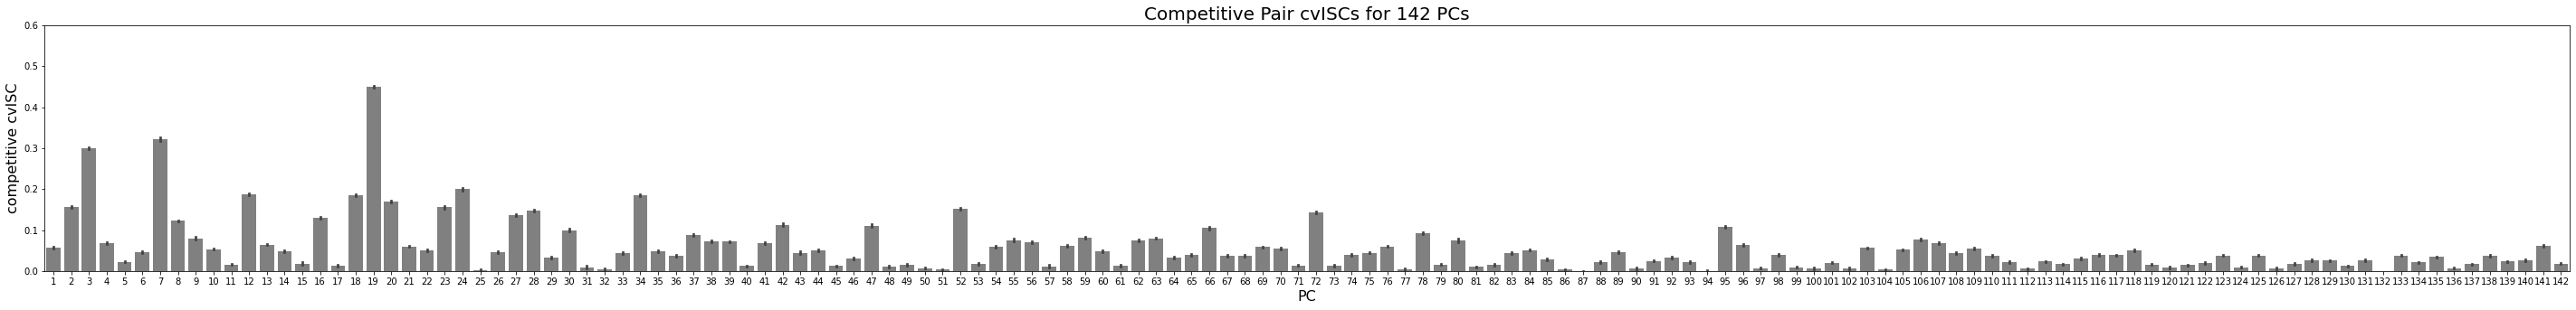

In [50]:
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='competitive cvISC', data=results_df_full, color='gray')
ax.set_ylim(0, .6)
ax.set_title('Competitive Pair cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('competitive cvISC', fontsize=16);
fig.savefig("comp_cvISC.png")

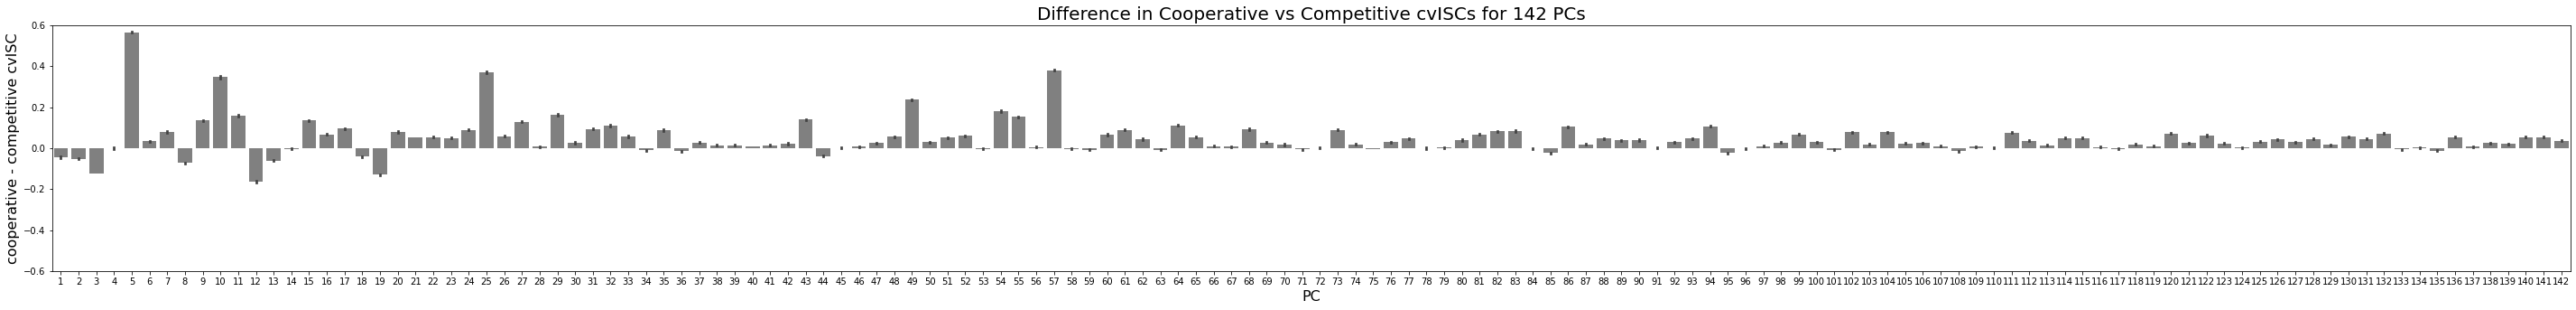

In [53]:
fig, ax = plt.subplots(figsize=(50, 5))
sns.barplot(x='PC', y='cooperative-competitive cvISC difference', data=results_df_full, color='gray')
ax.set_ylim(-.6, .6)
ax.set_title('Difference in Cooperative vs Competitive cvISCs for 142 PCs', fontsize=20)
plt.xlabel('PC', fontsize=16);
plt.ylabel('cooperative - competitive cvISC', fontsize=16);
fig.savefig("coop_comp_diff_cvISC.png")

In [9]:
wins = np.load(f'/jukebox/hasson/snastase/social-ctf/results/wins_matchup-0.npy')

In [10]:
scores = np.load(f'/jukebox/hasson/snastase/social-ctf/results/scores_matchup-0.npy')

In [165]:
scores.shape

(32, 32, 2)

In [157]:
ar = np.array([[[0],[1]],[[2],[3]],[[4],[5]]])
print(ar.shape)
np.hstack(np.split(ar, 3, axis=0)).squeeze()

(3, 2, 1)


array([0, 1, 2, 3, 4, 5])

In [11]:
wins_stack = np.hstack(np.split(wins, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
#wins_stack = np.hstack(np.split(wins_stack, n_maps, axis=0)).squeeze()
print(f"Wins stack shape: {wins_stack.shape}")

Wins stack shape: (1024, 2)


In [166]:
scores_stack = np.hstack(np.split(scores, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
#wins_stack = np.hstack(np.split(wins_stack, n_maps, axis=0)).squeeze()
print(f"Scores stack shape: {scores_stack.shape}")

Scores stack shape: (1024, 2)


In [105]:
pair = (0,1)
lstms_stack[train][:,pair, pc_id].shape

(4464992, 2)

In [109]:
results.shape

(142, 6, 1024)

In [98]:
results_wins = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LogisticRegression()
            reg.fit(results[pc_id, pair_id, train][:, np.newaxis], 
                    wins_stack[train, 0])
            pred = reg.predict(results[pc_id, pair_id, test][:, np.newaxis])
            result.extend([accuracy(p, t) for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(wins_stack[test, 0], n_repeats, axis=0))])
        results_wins[pc_id, pair_id] = np.array(result)
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}

NameError: name 'cv' is not defined

In [12]:
map_ids_2 = []
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        map_ids_2.append(map_id)
        
cv = PredefinedSplit(map_ids_2)
results_wins = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LogisticRegression(penalty="none")
            reg.fit(results[pc_id, pair_id, train][:, np.newaxis], 
                    wins_stack[train, 0])
            pred = reg.predict(results[pc_id, pair_id, test][:, np.newaxis])
            result.extend([accuracy_score(p, t) for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(wins_stack[test, 0], n_repeats, axis=0))])
        results_wins[pc_id, pair_id] = np.array(result)
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 0
Finished ISC regression for PC 2, pair 1
Finished ISC regression for PC 2, pair 2
Finished ISC regression for PC 2, pair 3
Finished ISC regression for PC 2, pair 4
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 0
Finished ISC regression for PC 3, pair 1
Finished ISC regression for PC 3, pair 2
Finished ISC regression for PC 3, pair 3
Finished ISC regression for PC 3, pair 4
Finished ISC regression for PC 3, pair 5
Finished ISC reg

In [4]:
#from sklearn.preprocessing import StandardScaler

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids_2)

results_wins = np.full((n_pcs, 2, n_maps), np.nan)   #n_repeats
for pc_id in np.arange(n_pcs):
    pairs = [(0,1),(2,3)]
    for pair_id, pair in enumerate(pairs):
        scores = []
        for f, (train, test) in enumerate(cv.split()):
            # Initialize simple classifier
            clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

            # Z-score training SPIs and test SPIs (based on training set)
            #scaler = StandardScaler()
            #print(len(test))
            #zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
            results_train = zscore(results[pc_id, pair_id, train][:, np.newaxis]) #scaler.fit_transform(results[pc_id, pair_id, train])
            results_test = zscore(results[pc_id, pair_id, test][:, np.newaxis]) #scaler.transform(results[pc_id, pair_id, test])

            # Train competitive/cooperative classifier based on train SPIs
            clf.fit(results_train, wins_stack[train, pair_id])

            # Use fitted classifier to predict test cooperative/competitive 
            pred = clf.predict(results_test)

            # Evaluate classifier accuracy
            score = accuracy_score(wins_stack[test, pair_id], pred)
            scores.append(score)
            #print(f"Fold {f} accuracy: {score:.3f} ({spi_label})")
            #result.extend([accuracy_score(p, t) for p, t in
            #               zip(np.split(pred, n_repeats, axis=0),
            #                   np.split(wins_stack[test, 0], n_repeats, axis=0))])
        results_wins[pc_id, pair_id] = np.array(scores)
    print(f"Finished wins regression for PC {pc_id}") #fold {fold}

NameError: name 'map_ids_2' is not defined

In [13]:
#from sklearn.preprocessing import StandardScaler

# Set up leave-one-map-out cross-validation
cv = PredefinedSplit(map_ids_2)

results_wins_multi = np.full((2, n_maps), np.nan)   #n_repeats
pairs = [(0,1),(2,3)]
for pair_id, pair in enumerate(pairs):
    scores = []
    for f, (train, test) in enumerate(cv.split()):
        # Initialize simple classifier
        clf = LogisticRegression(penalty='none', max_iter=300, class_weight='balanced') 

        # Z-score training SPIs and test SPIs (based on training set)
        #scaler = StandardScaler()
        #print(len(test))
        #zscore(np.moveaxis(data[..., :n_pcs], 0, 1), axis=0)
        results_train = zscore(np.moveaxis(results[..., pair_id, train],0,1)) #scaler.fit_transform(results[pc_id, pair_id, train])
        results_test = zscore(np.moveaxis(results[..., pair_id, test],0,1)) #scaler.transform(results[pc_id, pair_id, test])

        # Train competitive/cooperative classifier based on train SPIs
        clf.fit(results_train, wins_stack[train, pair_id])

        # Use fitted classifier to predict test cooperative/competitive 
        pred = clf.predict(results_test)

        # Evaluate classifier accuracy
        score = accuracy_score(wins_stack[test, pair_id], pred)
        scores.append(score)
        #print(f"Fold {f} accuracy: {score:.3f} ({spi_label})")
        #result.extend([accuracy_score(p, t) for p, t in
        #               zip(np.split(pred, n_repeats, axis=0),
        #                   np.split(wins_stack[test, 0], n_repeats, axis=0))])
    results_wins_multi[pair_id] = np.array(scores)
print(f"Finished wins regression")
#print(f"Finished wins regression for PC {pc_id}") #fold {fold}

Finished wins regression


In [18]:
wins_multi_coefs = clf.coef_

(1, 142)

In [ ]:
#run 1000 times, shuffle wins and losses
#permutation test, 1000 regressions, predict shuffled get results_wins_multi
shuffled = np.vstack([np.random.permutation(row) for row in wins_stack])
#remove pair_id loop - use diffs?

In [14]:
results_wins_multi

array([[0.71875, 0.78125, 0.75   , 0.75   , 0.6875 , 0.6875 , 0.8125 ,
        0.71875, 0.84375, 0.6875 , 0.8125 , 0.59375, 0.78125, 0.65625,
        0.75   , 0.71875, 0.78125, 0.8125 , 0.5625 , 0.6875 , 0.8125 ,
        0.6875 , 0.78125, 0.78125, 0.65625, 0.5625 , 0.71875, 0.75   ,
        0.84375, 0.625  , 0.625  , 0.71875],
       [0.5    , 0.4375 , 0.53125, 0.625  , 0.5625 , 0.46875, 0.53125,
        0.53125, 0.59375, 0.46875, 0.4375 , 0.4375 , 0.4375 , 0.5625 ,
        0.4375 , 0.5    , 0.65625, 0.6875 , 0.5625 , 0.5    , 0.5    ,
        0.28125, 0.5    , 0.4375 , 0.59375, 0.34375, 0.53125, 0.625  ,
        0.4375 , 0.53125, 0.5    , 0.53125]])

In [212]:
wins_stack

array([[1, 0],
       [1, 0],
       [0, 1],
       ...,
       [0, 1],
       [1, 0],
       [0, 1]])

In [260]:
shuffled = np.vstack([np.random.permutation(row) for row in wins_stack])
shuffled

array([[1, 0],
       [0, 1],
       [0, 1],
       ...,
       [1, 0],
       [1, 0],
       [1, 0]])

In [231]:
shuf = np.random.choice([0,1], size=1024)

In [252]:
wins_stack = np.hstack(np.split(wins, n_repeats, axis=0)).squeeze() #32 x 144032 x 2
#wins_stack = np.hstack(np.split(wins_stack, n_maps, axis=0)).squeeze()
wins_stack_copy = np.copy(wins_stack)
print(f"Wins stack shape: {wins_stack.shape}")
wins_stack

Wins stack shape: (1024, 2)


array([[1, 0],
       [1, 0],
       [0, 1],
       ...,
       [0, 1],
       [1, 0],
       [0, 1]])

In [257]:
wins_stack_copy

array([[0, 1],
       [0, 1],
       [1, 0],
       ...,
       [1, 0],
       [0, 1],
       [1, 0]])

In [256]:
np.random.shuffle(wins_stack_copy.T)

In [208]:
np.mean(results_wins_multi[(0,1), :], axis=0)

array([0.609375, 0.609375, 0.640625, 0.6875  , 0.625   , 0.578125,
       0.671875, 0.625   , 0.71875 , 0.578125, 0.625   , 0.515625,
       0.609375, 0.609375, 0.59375 , 0.609375, 0.71875 , 0.75    ,
       0.5625  , 0.59375 , 0.65625 , 0.484375, 0.640625, 0.609375,
       0.625   , 0.453125, 0.625   , 0.6875  , 0.640625, 0.578125,
       0.5625  , 0.625   ])

In [209]:
np.mean(np.mean(results_wins_multi[(0,1), :], axis=0))

0.6162109375

In [210]:
np.mean(np.mean(results_wins_multi[(0,1), :-7], axis=0))

0.621875

In [129]:
map_ids = []
n_samples = 4501
for map_id in np.arange(n_maps):
    for repeat_id in np.arange(n_repeats):
        map_ids.extend([map_id]*n_samples)

In [131]:
len(map_ids)

4609024

In [100]:
np.nanmean(results_wins[141, (0,5)])

0.52587890625

In [153]:
results.shape

(142, 6, 1024)

In [174]:
pred.shape

(992,)

In [191]:
results_scores_diffs = np.full((n_pcs, n_maps), np.nan)
for pc_id in np.arange(n_pcs):
    result=[]
    for fold, (train, test) in enumerate(cv.split()):
        reg = LinearRegression()
        reg.fit(results[pc_id, 0, train][:, np.newaxis]-results[pc_id, 5, train][:, np.newaxis], 
                scores_stack[train,0]-scores_stack[train,1])
        pred = reg.predict(results[pc_id, 0, test][:, np.newaxis]-results[pc_id, 5, test][:, np.newaxis])
        result.append(pearsonr(pred, scores_stack[test,0]-scores_stack[test,1])[0])
        #result.extend([pearsonr(p, t)[0] for p, t in
        #               zip(np.split(pred, n_repeats, axis=0),
        #                   np.split(scores_stack[test,0][:, np.newaxis]
        #                            -scores_stack[test,1][:, np.newaxis], n_repeats, axis=0))])
    results_scores_diffs[pc_id] = np.array(result)
    print(f"Finished ISC regression for PC {pc_id}") #fold {fold}

Finished ISC regression for PC 0
Finished ISC regression for PC 1
Finished ISC regression for PC 2
Finished ISC regression for PC 3
Finished ISC regression for PC 4
Finished ISC regression for PC 5
Finished ISC regression for PC 6
Finished ISC regression for PC 7
Finished ISC regression for PC 8
Finished ISC regression for PC 9
Finished ISC regression for PC 10
Finished ISC regression for PC 11
Finished ISC regression for PC 12
Finished ISC regression for PC 13
Finished ISC regression for PC 14
Finished ISC regression for PC 15
Finished ISC regression for PC 16
Finished ISC regression for PC 17
Finished ISC regression for PC 18
Finished ISC regression for PC 19
Finished ISC regression for PC 20
Finished ISC regression for PC 21
Finished ISC regression for PC 22
Finished ISC regression for PC 23
Finished ISC regression for PC 24
Finished ISC regression for PC 25
Finished ISC regression for PC 26
Finished ISC regression for PC 27
Finished ISC regression for PC 28
Finished ISC regression 

In [188]:
results_scores = np.full((n_pcs, 2, n_maps), np.nan)
for pc_id in np.arange(n_pcs):
    for pair_id, pair in enumerate([0,5]):
        result=[]
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(results[pc_id, pair, train][:, np.newaxis], scores_stack[train,pair_id])
            pred = reg.predict(results[pc_id, pair, test][:, np.newaxis])
            result.append(pearsonr(pred, scores_stack[test,pair_id])[0])
            #result.extend([pearsonr(p, t)[0] for p, t in
            #               zip(np.split(pred, n_repeats, axis=0),
            #                   np.split(scores_stack[test,0][:, np.newaxis]
            #                            -scores_stack[test,1][:, np.newaxis], n_repeats, axis=0))])
        results_scores[pc_id, pair_id] = np.array(result)
    print(f"Finished ISC regression for PC {pc_id}") #fold {fold}

Finished ISC regression for PC 0
Finished ISC regression for PC 1
Finished ISC regression for PC 2
Finished ISC regression for PC 3
Finished ISC regression for PC 4
Finished ISC regression for PC 5
Finished ISC regression for PC 6
Finished ISC regression for PC 7
Finished ISC regression for PC 8
Finished ISC regression for PC 9
Finished ISC regression for PC 10
Finished ISC regression for PC 11
Finished ISC regression for PC 12
Finished ISC regression for PC 13
Finished ISC regression for PC 14
Finished ISC regression for PC 15
Finished ISC regression for PC 16
Finished ISC regression for PC 17
Finished ISC regression for PC 18
Finished ISC regression for PC 19
Finished ISC regression for PC 20
Finished ISC regression for PC 21
Finished ISC regression for PC 22
Finished ISC regression for PC 23
Finished ISC regression for PC 24
Finished ISC regression for PC 25
Finished ISC regression for PC 26
Finished ISC regression for PC 27
Finished ISC regression for PC 28
Finished ISC regression 

In [164]:
results_scores = np.full((n_pcs, int(n_pairs), n_maps), np.nan)
for pc_id in np.arange(n_pcs):
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(results[pc_id, pair_id, train][:, np.newaxis], 
                    np.abs(scores_stack[:,0]-scores_stack[:,1]))
            pred = reg.predict(results[pc_id, pair_id, test][:, np.newaxis])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(np.abs(scores_stack[:,0]-scores_stack[:,1]), n_repeats, axis=0))])
        results_scores[pc_id, pair_id] = np.array(result)
    print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}

ValueError: Found input variables with inconsistent numbers of samples: [992, 1024]

In [188]:
results_scores[141]

array([[-0.19811356,  0.1101846 ,  0.06488985, ...,  0.11415241,
        -0.1479954 , -0.33243243],
       [-0.2083288 ,  0.15257161, -0.00236332, ...,  0.13749687,
         0.31066562,  0.54676627],
       [-0.0787147 ,  0.02441486, -0.1545938 , ...,  0.43215357,
         0.15910166,  0.29461576],
       [-0.06129727, -0.08367304, -0.0446481 , ..., -0.04798101,
         0.06589082,  0.19083324],
       [-0.11800929,  0.10995176,  0.09787931, ..., -0.04851776,
         0.02985566,  0.48308258],
       [ 0.34523725, -0.01651632, -0.0233636 , ...,  0.35292266,
        -0.11716494, -0.0169599 ]])

In [194]:
np.save('regression_wins_results.npy', results_wins)
np.save('regression_scores_results.npy', results_scores)

In [122]:
np.save('regression_wins_results.npy', results_wins)

In [123]:
results_wins = np.load('regression_wins_results.npy')
results_scores = np.load('regression_scores_results.npy')

In [181]:
results_scores.shape

(142, 32)

In [192]:
results_df_dict_scores = {'PC': [], 'score diffs coop': [], 'scores coop': []}#, 'score diffs comp': []} #'wins comp': [],

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps):# * n_repeats):
        #results_wins[pc_id, 5, game_id] = -results_wins[pc_id, 5, game_id]
        #wins_coop = np.mean(results_wins[pc_id, (0,1), game_id], axis=0)
        #wins_comp = np.mean(results_wins[pc_id, comp_ids, game_id], axis=0)
        scores_coop_diffs = np.mean(results_scores_diffs[pc_id])
        scores_coop = np.mean(results_scores[pc_id]) #np.mean(results_scores[pc_id, coop_ids, game_id], axis=0)
        #scores_comp = np.mean(results_scores[pc_id, comp_ids, game_id], axis=0)
        #results_df_dict_scores['wins coop'].append(wins_coop)
        results_df_dict_scores['score diffs coop'].append(scores_coop_diffs)
        results_df_dict_scores['scores coop'].append(scores_coop)
        #results_df_dict_scores['wins comp'].append(wins_comp)
        #results_df_dict_scores['score diffs comp'].append(scores_comp)
        results_df_dict_scores['PC'].append(pc_id + 1)

results_df_scores = pd.DataFrame(results_df_dict_scores)

In [25]:
results_df_dict_wins = {'PC': [], 'wins coop': []}

for pc_id in np.arange(n_pcs): 
    for game_id in np.arange(n_maps): #n_repeats
        #results_wins[pc_id, 5, game_id] = -results_wins[pc_id, 5, game_id]
        wins_coop = np.mean(results_wins[pc_id, (0,1), game_id], axis=0)
        #wins_comp = np.mean(results_wins[pc_id, comp_ids, game_id], axis=0)
        results_df_dict_wins['wins coop'].append(wins_coop)
        results_df_dict_wins['PC'].append(pc_id + 1)

results_df_wins = pd.DataFrame(results_df_dict_wins)

In [31]:
dict_wins_multi_coef = {'PC': [], 'coef': []}

for pc_id in np.arange(n_pcs): 
    dict_wins_multi_coef['coef'].append(wins_multi_coefs[0, pc_id])
    dict_wins_multi_coef['PC'].append(pc_id + 1)

df_wins_multi_coef = pd.DataFrame(dict_wins_multi_coef)

In [32]:
df_wins_multi_coef

,PC,coef
0,1,0.006735
1,2,-0.075171
2,3,-0.005883
3,4,-0.072007
4,5,0.145161
...,...,...
137,138,0.041263
138,139,0.176519
139,140,0.020286
140,141,0.039459


(-0.3, 0.3)

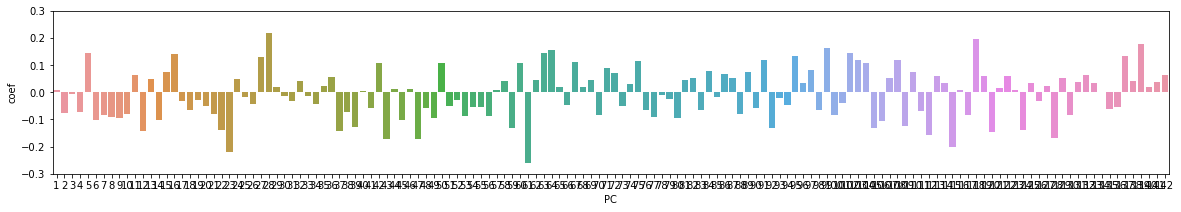

In [35]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='coef', data=pd.DataFrame(df_wins_multi_coef))
ax.set_ylim(-0.3, .3)

(0.3, 0.7)

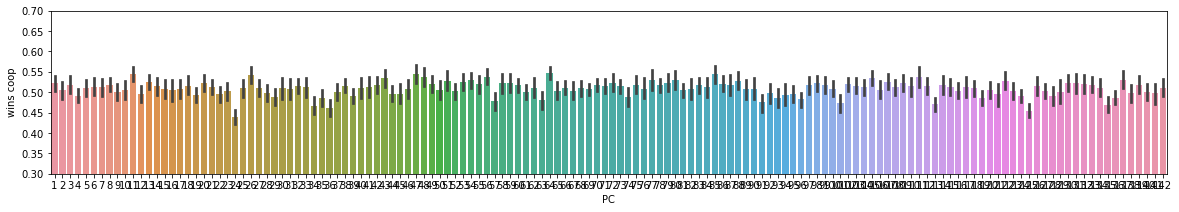

In [198]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='wins coop', data=results_df_wins)
ax.set_ylim(0.3, .7)

(0.0, 0.3)

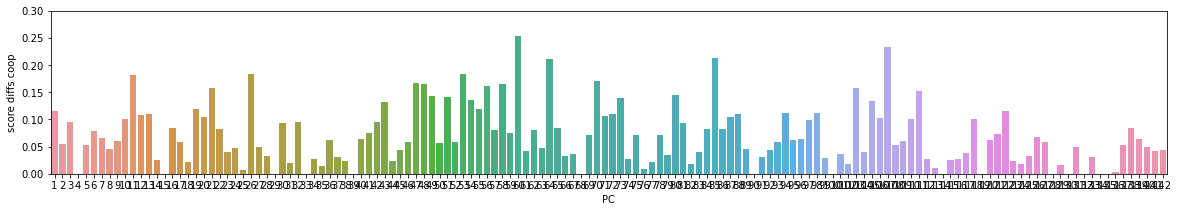

In [199]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='score diffs coop', data=results_df_scores)
ax.set_ylim(0, .3)

(0.0, 0.3)

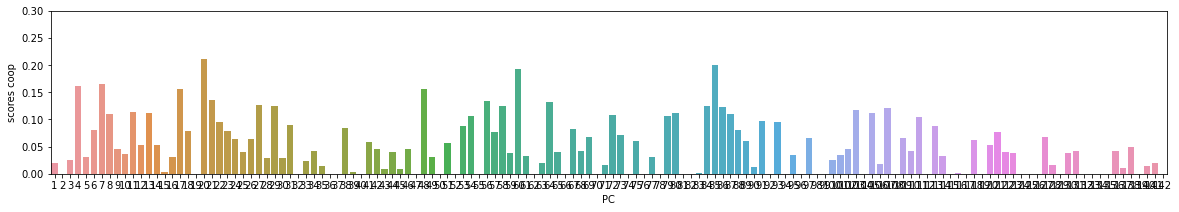

In [194]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='scores coop', data=results_df_scores)
ax.set_ylim(0, .3)

(0.0, 0.3)

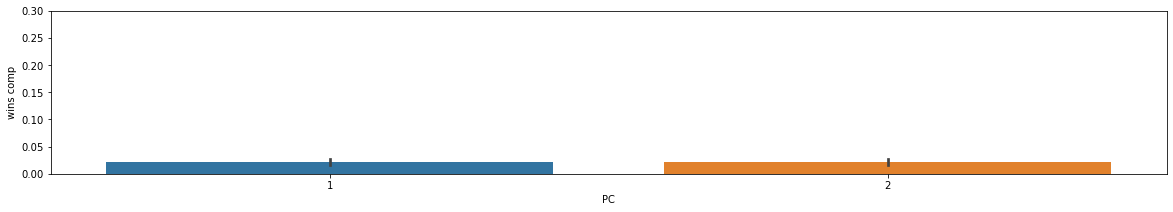

In [ ]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='wins comp', data=results_df_scores)
ax.set_ylim(0, .3)

(0.0, 0.3)

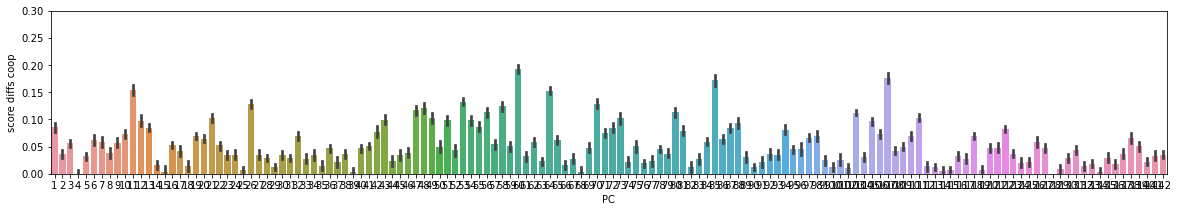

In [191]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='score diffs coop', data=results_df_scores)
ax.set_ylim(0, .3)

(0.0, 0.3)

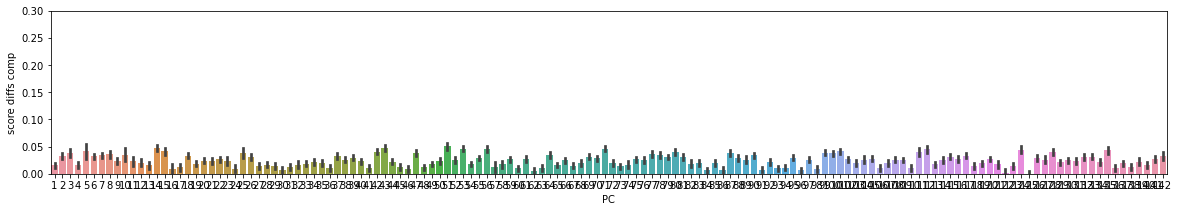

In [192]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='score diffs comp', data=results_df_scores)
ax.set_ylim(0, .3)

In [ ]:
#now for multivariate
print('yay!')

In [ ]:
from sklearn.model_selection import PredefinedSplit
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

cv = PredefinedSplit(map_ids)

results_multi_var = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(5): #n_pcs
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in enumerate(cv.split()):
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0]], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0]])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results_multi_var[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 2


In [57]:
np.load('regression_results_multi_{pc_id}.npy')

array([[0.52793319, 0.52554644, 0.58406144, ..., 0.5637844 , 0.46353088,
        0.58101505],
       [0.50052802, 0.56661801, 0.51880854, ..., 0.51975396, 0.41763685,
        0.5185217 ],
       [0.43897262, 0.49456881, 0.53653529, ..., 0.54909829, 0.49878558,
        0.49582986],
       [0.50333397, 0.56841473, 0.61639649, ..., 0.5085437 , 0.46603044,
        0.44826873],
       [0.43121978, 0.47572979, 0.47591924, ..., 0.5383057 , 0.44482695,
        0.53820833],
       [0.50117127, 0.51903216, 0.47225111, ..., 0.50250335, 0.46700242,
        0.52897097]])

In [86]:
results_multi_var = np.full((n_pcs, int(n_pairs), n_maps*n_repeats), np.nan)
for pc_id in np.arange(n_pcs):
    results_multi_var[pc_id] = np.load(f'regression_results_multi_{pc_id}.npy')

In [78]:
results_multi_var[19]

array([[0.41838028, 0.54233072, 0.44271822, ..., 0.46822044, 0.41399907,
        0.48669554],
       [0.49542144, 0.51744599, 0.46842203, ..., 0.45997889, 0.3588165 ,
        0.52427189],
       [0.40495171, 0.54466001, 0.54937446, ..., 0.55370611, 0.49585447,
        0.49688865],
       [0.53588288, 0.54150065, 0.57981829, ..., 0.41594652, 0.40742208,
        0.3958055 ],
       [0.4460597 , 0.61222541, 0.51227517, ..., 0.47934217, 0.50180969,
        0.4757409 ],
       [0.49749135, 0.60471807, 0.54270825, ..., 0.54513222, 0.49051741,
        0.42632025]])

In [87]:
results_multi_var_df_dict_full = {'PC': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'coop/comp difference cvISC': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(n_pcs):
    for game_id in np.arange(n_maps * n_repeats):
        coop = np.mean(results_multi_var[pc_id, coop_ids, game_id], axis=0)
        comp = np.mean(results_multi_var[pc_id, comp_ids, game_id], axis=0)
        results_multi_var_df_dict_full['cooperative cvISC'].append(coop)
        results_multi_var_df_dict_full['competitive cvISC'].append(comp)
        results_multi_var_df_dict_full['coop/comp difference cvISC'].append(coop-comp)
        results_multi_var_df_dict_full['PC'].append(pc_id + 1)

results_df_multi_var = pd.DataFrame(results_multi_var_df_dict_full)

(0.0, 1.0)

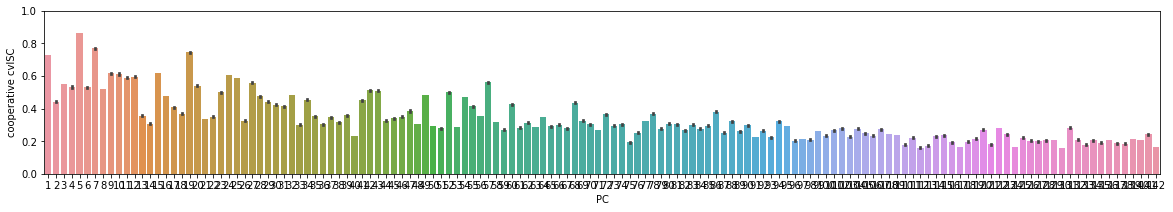

In [91]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_multi_var, ax=ax)
ax.set_ylim(0, 1)

In [ ]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_multi_var, ax=ax)
ax.set_ylim(0, 1)
# subtract out the 1-1 PC regression

(0.0, 1.0)

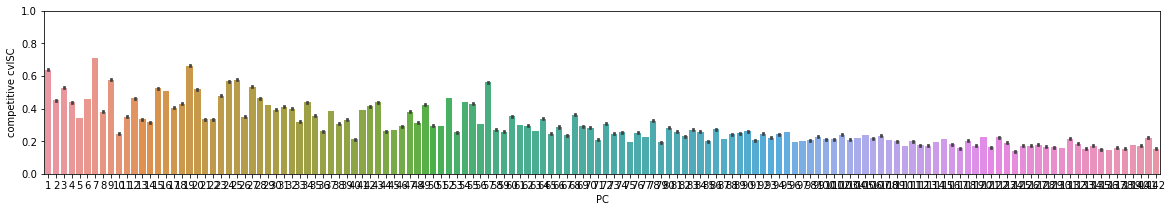

In [92]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='competitive cvISC', data=results_df_multi_var, ax=ax)
ax.set_ylim(0, 1)

(-0.8, 0.8)

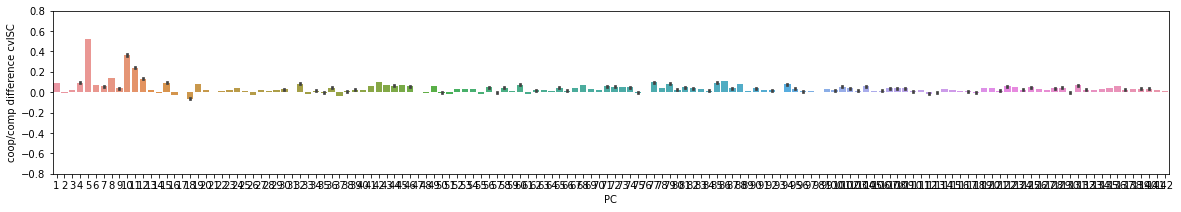

In [93]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='coop/comp difference cvISC', data=results_df_multi_var)
ax.set_ylim(-.8, .8)

In [ ]:
results_multi_var_1_fold = np.full((n_pcs, int(n_pairs), n_repeats), np.nan)
for pc_id in np.arange(20): #n_pcs
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in zip(range(1),cv.split()): #(1) fold
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0]], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0]])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results_multi_var_1_fold[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 0, pair 0
Finished ISC regression for PC 0, pair 1
Finished ISC regression for PC 0, pair 2
Finished ISC regression for PC 0, pair 3
Finished ISC regression for PC 0, pair 4
Finished ISC regression for PC 0, pair 5
Finished ISC regression for PC 1, pair 0
Finished ISC regression for PC 1, pair 1
Finished ISC regression for PC 1, pair 2
Finished ISC regression for PC 1, pair 3
Finished ISC regression for PC 1, pair 4
Finished ISC regression for PC 1, pair 5
Finished ISC regression for PC 2, pair 0
Finished ISC regression for PC 2, pair 1
Finished ISC regression for PC 2, pair 2
Finished ISC regression for PC 2, pair 3
Finished ISC regression for PC 2, pair 4
Finished ISC regression for PC 2, pair 5
Finished ISC regression for PC 3, pair 0
Finished ISC regression for PC 3, pair 1
Finished ISC regression for PC 3, pair 2
Finished ISC regression for PC 3, pair 3
Finished ISC regression for PC 3, pair 4
Finished ISC regression for PC 3, pair 5
Finished ISC reg

In [85]:
for pc_id in np.arange(50,100): #n_pcs
    pairs = combinations(np.arange(n_players), 2)
    for pair_id, pair in enumerate(pairs):
        result = []
        for fold, (train, test) in zip(range(1),cv.split()): #(1) fold
            reg = LinearRegression()
            reg.fit(lstms_stack[train, pair[0]], 
                    lstms_stack[train, pair[1], pc_id])
            pred = reg.predict(lstms_stack[test, pair[0]])
            result.extend([pearsonr(p, t)[0] for p, t in
                           zip(np.split(pred, n_repeats, axis=0),
                               np.split(lstms_stack[test, pair[1], pc_id], n_repeats, axis=0))])
        print(f"Finished ISC regression for PC {pc_id}, pair {pair_id}") #fold {fold}
        results_multi_var_1_fold[pc_id, pair_id] = np.array(result)

Finished ISC regression for PC 50, pair 0
Finished ISC regression for PC 50, pair 1
Finished ISC regression for PC 50, pair 2
Finished ISC regression for PC 50, pair 3
Finished ISC regression for PC 50, pair 4
Finished ISC regression for PC 50, pair 5
Finished ISC regression for PC 51, pair 0
Finished ISC regression for PC 51, pair 1
Finished ISC regression for PC 51, pair 2
Finished ISC regression for PC 51, pair 3
Finished ISC regression for PC 51, pair 4
Finished ISC regression for PC 51, pair 5
Finished ISC regression for PC 52, pair 0
Finished ISC regression for PC 52, pair 1
Finished ISC regression for PC 52, pair 2
Finished ISC regression for PC 52, pair 3
Finished ISC regression for PC 52, pair 4
Finished ISC regression for PC 52, pair 5
Finished ISC regression for PC 53, pair 0
Finished ISC regression for PC 53, pair 1
Finished ISC regression for PC 53, pair 2
Finished ISC regression for PC 53, pair 3
Finished ISC regression for PC 53, pair 4
Finished ISC regression for PC 53,

In [86]:
results_multi_var_1_fold[99]

array([[0.07681388, 0.21202461, 0.25787226, 0.20615756, 0.2141895 ,
        0.21273822, 0.25105415, 0.18066654, 0.27605733, 0.21727095,
        0.11746758, 0.16344844, 0.20146377, 0.2175827 , 0.24646366,
        0.2523867 , 0.19189555, 0.03768507, 0.16529588, 0.19862142,
        0.2532388 , 0.21462117, 0.19990145, 0.20377551, 0.20708991,
        0.24214104, 0.10316852, 0.22985793, 0.25352327, 0.14885263,
        0.15719031, 0.30606742],
       [0.2584183 , 0.17972688, 0.32210771, 0.18145032, 0.22209492,
        0.26819729, 0.2439721 , 0.23067625, 0.28229641, 0.23654318,
        0.1368754 , 0.20139029, 0.13058723, 0.13094567, 0.23737257,
        0.27325071, 0.26636178, 0.2327637 , 0.2242996 , 0.20196402,
        0.17859131, 0.25240265, 0.28580981, 0.16381978, 0.25284457,
        0.17553455, 0.11404146, 0.06090522, 0.10065745, 0.29020174,
        0.26356158, 0.17287335],
       [0.17463691, 0.22122147, 0.28304223, 0.25653284, 0.20257332,
        0.25152359, 0.15518079, 0.14218124, 0.0395

In [87]:
np.save('regression_results_multi_1_fold.npy', results_multi_var_1_fold)

In [93]:
results_multi_var_1_fold = np.load('regression_results_multi_1_fold.npy')

In [94]:
results_multi_var_1_fold_t[99]

array([[0.07681388, 0.21202461, 0.25787226, 0.20615756, 0.2141895 ,
        0.21273822, 0.25105415, 0.18066654, 0.27605733, 0.21727095,
        0.11746758, 0.16344844, 0.20146377, 0.2175827 , 0.24646366,
        0.2523867 , 0.19189555, 0.03768507, 0.16529588, 0.19862142,
        0.2532388 , 0.21462117, 0.19990145, 0.20377551, 0.20708991,
        0.24214104, 0.10316852, 0.22985793, 0.25352327, 0.14885263,
        0.15719031, 0.30606742],
       [0.2584183 , 0.17972688, 0.32210771, 0.18145032, 0.22209492,
        0.26819729, 0.2439721 , 0.23067625, 0.28229641, 0.23654318,
        0.1368754 , 0.20139029, 0.13058723, 0.13094567, 0.23737257,
        0.27325071, 0.26636178, 0.2327637 , 0.2242996 , 0.20196402,
        0.17859131, 0.25240265, 0.28580981, 0.16381978, 0.25284457,
        0.17553455, 0.11404146, 0.06090522, 0.10065745, 0.29020174,
        0.26356158, 0.17287335],
       [0.17463691, 0.22122147, 0.28304223, 0.25653284, 0.20257332,
        0.25152359, 0.15518079, 0.14218124, 0.0395

In [89]:
results_multi_var_df_dict_1_fold_full = {'PC': [], 'cooperative cvISC': [], 'competitive cvISC': [], 'coop/comp difference cvISC': []}

coop_ids = (0, 5)
comp_ids = (1, 2, 3, 4)
for pc_id in np.arange(100):  #n_pcs
    for game_id in np.arange(n_repeats):
        coop = np.mean(results_multi_var_1_fold[pc_id, coop_ids, game_id], axis=0)
        comp = np.mean(results_multi_var_1_fold[pc_id, comp_ids, game_id], axis=0)
        results_multi_var_df_dict_1_fold_full['cooperative cvISC'].append(coop)
        results_multi_var_df_dict_1_fold_full['competitive cvISC'].append(comp)
        results_multi_var_df_dict_1_fold_full['coop/comp difference cvISC'].append(coop-comp)
        results_multi_var_df_dict_1_fold_full['PC'].append(pc_id + 1)

results_df_multi_var_1_fold = pd.DataFrame(results_multi_var_df_dict_1_fold_full)

In [80]:
results_df_multi_var_1_fold

,PC,cooperative cvISC,competitive cvISC,coop/comp difference cvISC
0,1,0.661143,0.645369,0.015773
1,1,0.729626,0.662410,0.067216
2,1,0.701120,0.608945,0.092175
3,1,0.739786,0.607875,0.131911
4,1,0.705992,0.617465,0.088527
...,...,...,...,...
1595,50,0.296329,0.297180,-0.000851
1596,50,0.322205,0.335826,-0.013621
1597,50,0.304282,0.305930,-0.001648
1598,50,0.274095,0.311687,-0.037592


(0.0, 1.0)

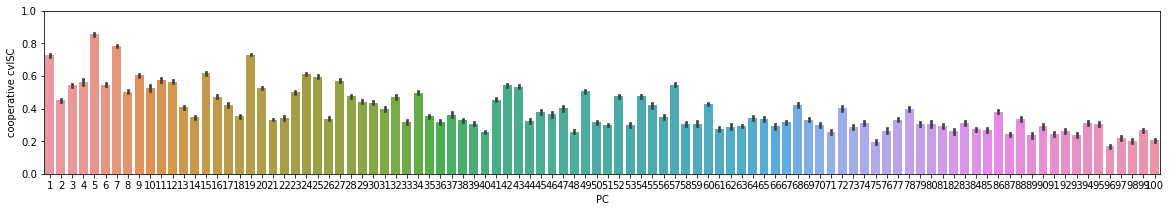

In [90]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='cooperative cvISC', data=results_df_multi_var_1_fold, ax=ax)
ax.set_ylim(0, 1)

(0.0, 1.0)

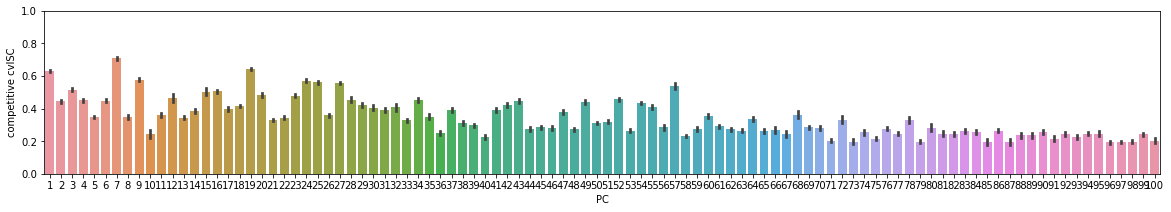

In [91]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='competitive cvISC', data=results_df_multi_var_1_fold, ax=ax)
ax.set_ylim(0, 1)

(-0.7, 0.7)

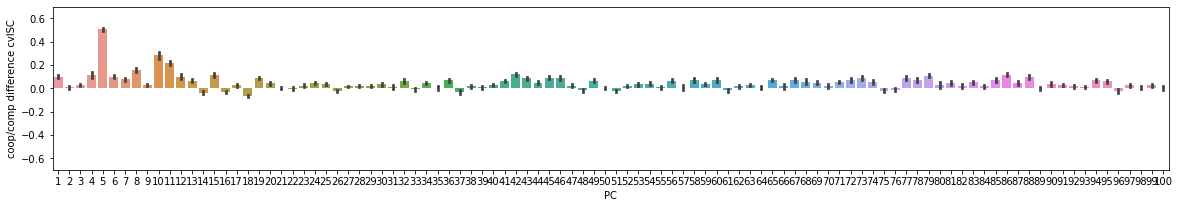

In [92]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.barplot(x='PC', y='coop/comp difference cvISC', data=results_df_multi_var_1_fold)
ax.set_ylim(-.7, .7)